<a href="https://colab.research.google.com/github/sukritimahajan35/Hindi-Audio-Sentiment-Analysis-Using-Machine-Learning-and-Deep-Learning/blob/main/MultiInput_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mount Google Drive (Optional, if dataset is on Google Drive)
from google.colab import drive
drive.mount('/content/drive')

# Navigate to Dataset Directory
dataset_path = '/content/drive/MyDrive/Dataset'
os.chdir(dataset_path)

Mounted at /content/drive


In [ ]:
# Extract File Paths and Labels
def extract_dataset(base_path):
    data = []
    emotions = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']

    # Sort actor folders numerically
    actor_folders = sorted(os.listdir(base_path), key=lambda x: int(x))

    for actor_folder in actor_folders:
        actor_path = os.path.join(base_path, actor_folder)
        if os.path.isdir(actor_path):
            # Sort session folders numerically
            session_folders = sorted(os.listdir(actor_path), key=lambda x: int(x.split('session')[-1]))

            for session_folder in session_folders:
                session_path = os.path.join(actor_path, session_folder)
                if os.path.isdir(session_path):
                    for emotion in emotions:
                        emotion_path = os.path.join(session_path, emotion)
                        if os.path.isdir(emotion_path):
                            # Sort audio files numerically
                            audio_files = sorted(os.listdir(emotion_path), key=lambda x: int(x.split('-')[-1].split('.')[0]))

                            for audio_file in audio_files:
                                data.append((os.path.join(emotion_path, audio_file), emotion))
    return pd.DataFrame(data, columns=['file_path', 'emotion'])

# Extract dataset
df = extract_dataset(dataset_path)
print(df.head())

                                           file_path emotion
0  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
1  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
2  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
3  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
4  /content/drive/MyDrive/Dataset/1/session1/ange...   anger


In [ ]:
# Data Augmentation
def augment_audio(y, sr):
    augmented_samples = []

    # Original signal
    augmented_samples.append(y)

    # Pitch shifting
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
    augmented_samples.append(y_pitch)

    # Time stretching
    y_stretch = librosa.effects.time_stretch(y, rate=0.8)
    augmented_samples.append(y_stretch)# Add background noise
    noise = np.random.randn(len(y)) * 0.005
    y_noisy = y + noise
    augmented_samples.append(y_noisy)

    return augmented_samples

In [ ]:
# Feature Extraction: Mel-Spectrogram
def extract_mel_spectrogram(y, sr=22050, max_length=None):
    """
    Convert audio signal to Mel-spectrogram.
    """
    # Set default max_length if not provided
    if max_length is None:
        max_length = 3 * sr  # Default to 3 seconds of audio

    try:
        # Handle short signals
        if len(y) < max_length:
            y = np.pad(y, (0, max_length - len(y)), mode='constant')  # Pad short signals
        else:
            y = y[:max_length]  # Truncate long signals

        # Generate Mel-spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Resize to fixed dimensions (e.g., 128x128)
        mel_spectrogram_resized = librosa.util.fix_length(mel_spectrogram_db, size=128, axis=1)
        return mel_spectrogram_resized

    except Exception as e:
        print(f"Error extracting Mel-spectrogram: {e}")
        return None

In [ ]:
# Feature Extraction: Extract MFCC, Zero-Crossing Rate, Spectral Centroid, Chroma Features, RMSE
def extract_audio_features(y, sr=22050):
    """
    Extract advanced audio features: MFCC, Zero-Crossing Rate, Spectral Centroid, Chroma Features, RMSE.
    """
    try:
        # Extract Features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)  # MFCC
        zcr = librosa.feature.zero_crossing_rate(y).mean()  # Zero-Crossing Rate
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()  # Spectral Centroid
        chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)  # Chroma Features
        rmse = librosa.feature.rms(y=y).mean()  # Root Mean Square Energy

        # Combine all features into a single vector
        features = np.hstack([mfcc, zcr, spectral_centroid, chroma, rmse])
        return features
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

In [ ]:
# Preprocessing Pipeline with Augmentation and Feature Extraction
def preprocess_data(df):
    mel_spectrograms = []
    feature_vectors = []
    labels = []
    for idx, row in df.iterrows():
        try:
            y, sr = librosa.load(row['file_path'], sr=None)

            # Step 1: Noise Reduction (Optional)
            y = librosa.effects.preemphasis(y)

            # Step 2: Silence Removal (Optional)
            intervals = librosa.effects.split(y, top_db=20)
            y = np.concatenate([y[start:end] for start, end in intervals])

            # Step 3: Data Augmentation
            augmented_signals = augment_audio(y, sr)

            # Step 4: Feature Extraction
            for augmented_signal in augmented_signals:
                # Extract Mel-Spectrogram
                mel_spec = extract_mel_spectrogram(augmented_signal, sr)
                if mel_spec is not None:
                    mel_spectrograms.append(mel_spec)

                # Extract Combined Features
                feature_vector = extract_audio_features(augmented_signal, sr)
                if feature_vector is not None:feature_vectors.append(feature_vector)

                # Append Label
                labels.append(row['emotion'])
        except Exception as e:
            print(f"Error processing file {row['file_path']}: {e}")

    mel_spectrograms = np.array(mel_spectrograms)
    feature_vectors = np.array(feature_vectors)
    return mel_spectrograms, feature_vectors, np.array(labels)

# Apply Preprocessing
mel_spectrograms, feature_vectors, y = preprocess_data(df)

In [ ]:
# Encode Labels and Split Data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split Data
X_train_mel, X_test_mel, X_train_features, X_test_features, y_train, y_test = train_test_split(
    mel_spectrograms, feature_vectors, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
# Standardize 1D Features
scaler = StandardScaler()
X_train_features = scaler.fit_transform(X_train_features)
X_test_features = scaler.transform(X_test_features)

# Add Channel Dimension for Mel-Spectrogram
X_train_mel = X_train_mel[..., np.newaxis]
X_test_mel = X_test_mel[..., np.newaxis]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Build Multi-Input Model
def build_multi_input_model(input_shape_mel, input_shape_features, num_classes):
    # Input 1: Mel-Spectrogram
    input_mel = Input(shape=input_shape_mel)
    x = Conv2D(32, (3, 3), activation='relu')(input_mel)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = GlobalAveragePooling2D()(x)

    # Input 2: Combined Features
    input_features = Input(shape=input_shape_features)
    y = Dense(128, activation='relu')(input_features)
    y = Dropout(0.5)(y)
    y = Dense(64, activation='relu')(y)

    # Combine Outputs
    combined = Concatenate()([x, y])

    # Final Layers
    z = Dense(128, activation='relu')(combined)
    z = Dropout(0.5)(z)
    predictions = Dense(num_classes, activation='softmax')(z)

    # Create Model
    model = Model(inputs=[input_mel, input_features], outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train Multi-Input Model
multi_input_model = build_multi_input_model(input_shape_mel=(128, 128, 1), input_shape_features=(X_train_features.shape[1],), num_classes=len(np.unique(y_encoded)))

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = multi_input_model.fit(
    [X_train_mel, X_train_features], y_train,
    epochs=50,batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Evaluate Multi-Input Model
y_pred = np.argmax(multi_input_model.predict([X_test_mel, X_test_features]), axis=1)
print("Accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1625 - loss: 2.1986 - val_accuracy: 0.2881 - val_loss: 1.9029 - learning_rate: 0.0010
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.2538 - loss: 1.9196 - val_accuracy: 0.3345 - val_loss: 1.7352 - learning_rate: 0.0010
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3108 - loss: 1.7963 - val_accuracy: 0.3735 - val_loss: 1.6644 - learning_rate: 0.0010
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3453 - loss: 1.7098 - val_accuracy: 0.3848 - val_loss: 1.6111 - learning_rate: 0.0010
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3533 - loss: 1.6525 - val_accuracy: 0.4219 - val_loss: 1.5417 - learning_rate: 0.0010
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3715 - loss: 1.6231 - val_accuracy: 0.4639 - val_loss: 1.4890 - learning_rate: 0.0010
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4010 - loss: 1.

In [ ]:
# Classification Report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

       anger       0.77      0.82      0.79       288
     disgust       0.65      0.66      0.66       329
        fear       0.73      0.69      0.71       312
       happy       0.71      0.69      0.70       344
     neutral       0.71      0.64      0.67       317
         sad       0.69      0.70      0.69       327
   sarcastic       0.65      0.44      0.52       328
    surprise       0.60      0.85      0.70       315

    accuracy                           0.68      2560
   macro avg       0.69      0.69      0.68      2560
weighted avg       0.69      0.68      0.68      2560



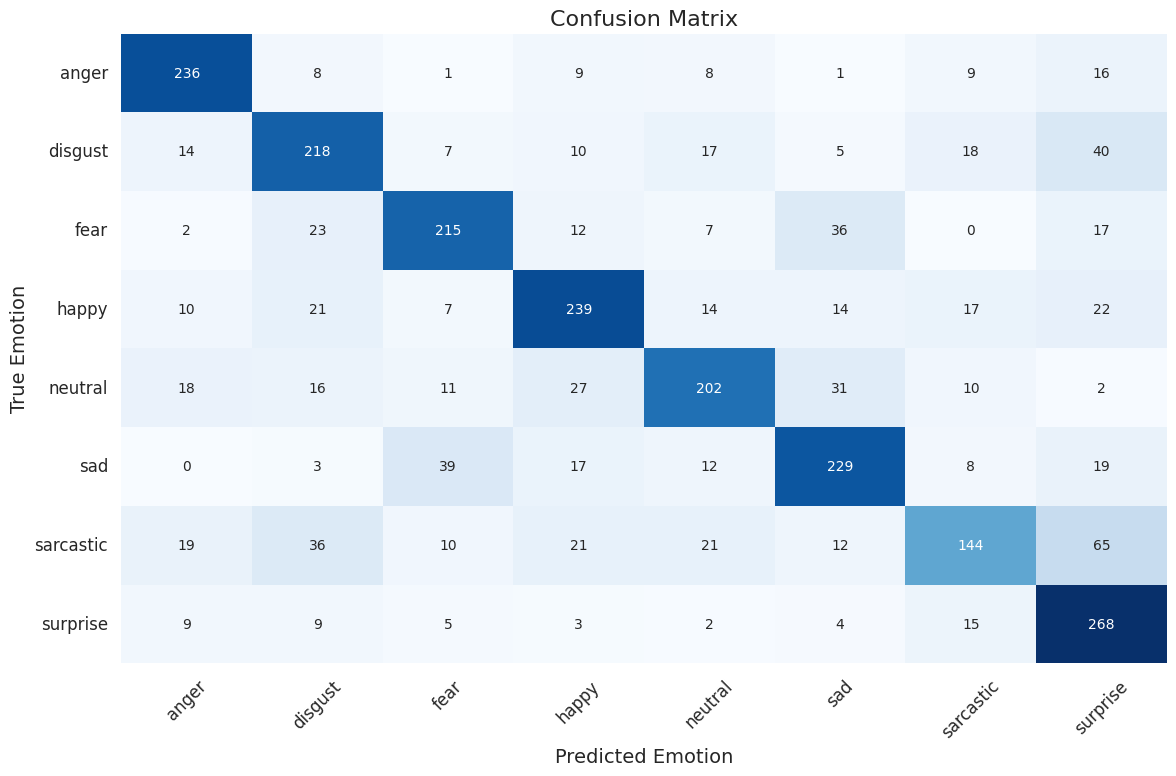

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)  # Adjust font size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={"size": 10}, cbar=False)

# Add Labels and Title
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Emotion', fontsize=14)
plt.ylabel('True Emotion', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()  # Adjust layout for better visualization
plt.show()